In [2]:
import os
import pandas as pd
import Config
import pickle

In [2]:
dir_rawFiles = '../Databases/ICBHI/audio_and_txt_files/'

all_rows = []

for file_name in sorted(os.listdir(dir_rawFiles)):

    if not file_name.endswith('.txt'):
        continue

    #read txt file and store timings
    with open(f"{dir_rawFiles}{file_name}", "r") as f:
        for line in f:
            eStart, eEnd, crackle, wheeze = line.strip().split("\t")
            
            all_rows.append({
                'File': file_name,
                'Seg_start': float(eStart),
                'Seg_end': float(eEnd),
                'Seg_crackle': crackle,
                'Seg_wheeze': wheeze
            })

    allSegs = pd.DataFrame(all_rows)
    
    


In [3]:
allSegs['Seg_length'] = allSegs['Seg_end'] - allSegs['Seg_start']

In [4]:
allSegs

,File,Seg_start,Seg_end,Seg_crackle,Seg_wheeze,Seg_length
0,101_1b1_Al_sc_Meditron.txt,0.036,0.579,0,0,0.543
1,101_1b1_Al_sc_Meditron.txt,0.579,2.450,0,0,1.871
2,101_1b1_Al_sc_Meditron.txt,2.450,3.893,0,0,1.443
3,101_1b1_Al_sc_Meditron.txt,3.893,5.793,0,0,1.900
4,101_1b1_Al_sc_Meditron.txt,5.793,7.521,0,0,1.728
...,...,...,...,...,...,...
6893,226_1b1_Pl_sc_LittC2SE.txt,11.721,13.693,1,0,1.972
6894,226_1b1_Pl_sc_LittC2SE.txt,13.693,15.536,0,0,1.843
6895,226_1b1_Pl_sc_LittC2SE.txt,15.536,17.493,0,0,1.957
6896,226_1b1_Pl_sc_LittC2SE.txt,17.493,19.436,1,0,1.943


array([[<Axes: title={'center': 'Seg_length'}>]], dtype=object)

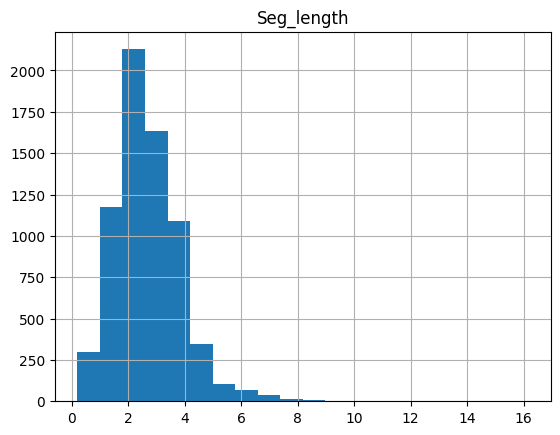

In [5]:
allSegs.hist('Seg_length',bins=20)

In [8]:
allSegs['Seg_length'].argmax()

3667

In [10]:
allSegs.iloc[3667]

File           166_1p1_Al_sc_Meditron.txt
Seg_start                          16.703
Seg_end                            32.866
Seg_crackle                             0
Seg_wheeze                              0
Seg_length                         16.163
Name: 3667, dtype: object

In [94]:
min_seg_length = 1.0
max_seg_length = 4.096

lenAll = len(allSegs)
lenBelow = len(allSegs[allSegs['Seg_length']<min_seg_length])
lenAbove = len(allSegs[allSegs['Seg_length']>max_seg_length])

#displaying number of points removed and %
print(f'Total number of points: {lenAll}')
print(f'Number of points below min threshold: {lenBelow} - ({100*lenBelow/lenAll:0.2f}%)')
print(f'Number of points above max threshold: {lenAbove} - ({100*lenAbove/lenAll:0.2f}%)')
print(f'Total number of points removed: {lenBelow + lenAbove} - ({100*(lenBelow +lenAbove)/lenAll:0.2f}%)')


Total number of points: 6898
Number of points below min threshold: 297 - (4.31%)
Number of points above max threshold: 700 - (10.15%)
Total number of points removed: 997 - (14.45%)


In [23]:
min_seg_length = 1.0
max_seg_length = 5.0
len(allSegs[allSegs['Seg_length']<min_seg_length])

297

In [5]:
import pickle 

def data_Acq(fileName):
    file = open(fileName, 'rb')
    sample = pickle.load(file, encoding='latin1')
    file.close()

    return sample


def dc_normalise(sig_array):
    """Removes DC and normalizes to -1, 1 range"""
    sig_array_norm = sig_array.copy()
    sig_array_norm -= sig_array_norm.mean()
    sig_array_norm /= abs(sig_array_norm).max()
    return sig_array_norm

import librosa
import numpy as np
import matplotlib.pyplot as plt

def create_mel_spectrogram(data, sample_rate, n_mels=128, f_min=50, f_max=1800, winLength = 256, nfft = 256, hop=256, show_function=True):
    S = librosa.feature.melspectrogram(y=data, sr=sample_rate, n_mels=n_mels, fmin=f_min, fmax=f_max,
                                       win_length = winLength, n_fft=nfft, hop_length=hop,center=False)
    S = librosa.power_to_db(S, ref=np.max)
    S = (S - S.min()) / (S.max() - S.min())

    if show_function:
        fig, ax = plt.subplots()
        fig.set_size_inches(8,3)

        img = librosa.display.specshow(S, x_axis='time',
                                       y_axis='mel', sr=sample_rate, hop_length = hop,
                                       fmax=f_max, ax=ax)
        plt.show()

    return S

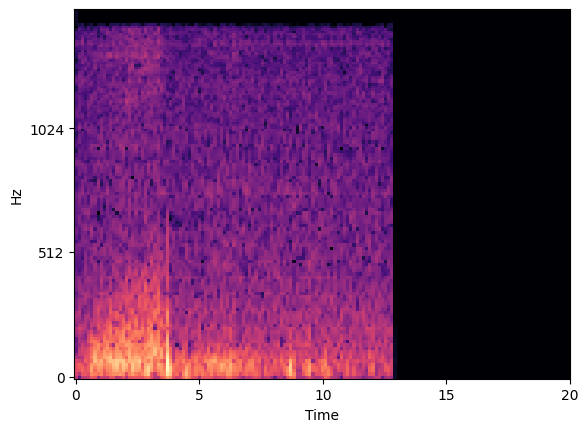

In [43]:
#looping through each dat file saved in dir_preprocessed
allDatFiles = os.listdir(Config.dir_preprocessed)
allDatFiles = [allDatFiles[0]]

for datFileName in allDatFiles:
    
    # Extracting data from dat file
    path_datFile = f"{Config.dir_preprocessed}/{datFileName}"
    samples = data_Acq(path_datFile)

    # removing DC component and normalising to -1/1 window
    data = dc_normalise(samples["signal"])

    # Mel spectrogram
    mel_spectrogram = create_mel_spectrogram(data, Config.sample_rate, Config.n_mels,
                                                Config.f_min, Config.f_max, Config.nfft, Config.hop,show_function=True)

In [67]:
print(f'Num rows: {len(mel_spectrogram)}')
print(f'Num cols: {len(mel_spectrogram[0])}')

Num rows: 128
Num cols: 157


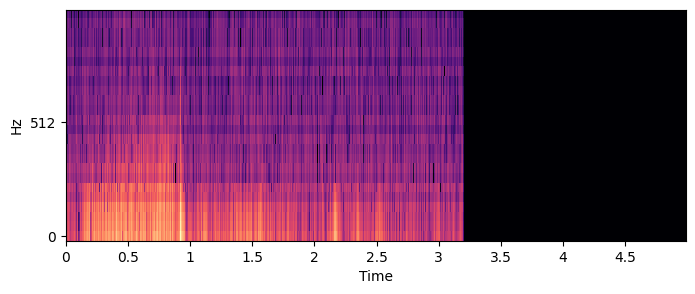

In [109]:
S1 = create_mel_spectrogram(data, Config.sample_rate, n_mels=24, f_min=100, f_max=1000, winLength=32, nfft = 64, hop=16, show_function=True)

In [101]:
print(f'Num rows: {len(S1)}')
print(f'Num cols: {len(S1[0])}')

Num rows: 16
Num cols: 624


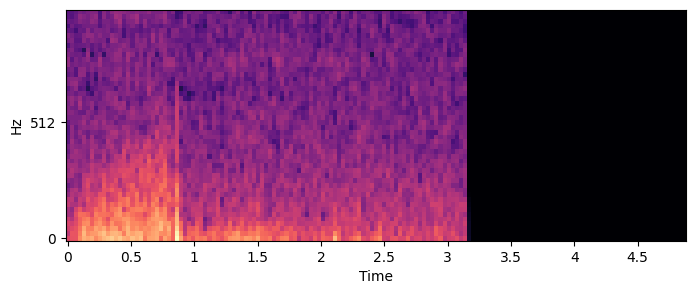

In [110]:
S2 = create_mel_spectrogram(data, Config.sample_rate, n_mels=48, f_min=100, f_max=1000, winLength=256,nfft=512, hop=128, show_function=True)

In [103]:
print(f'Num rows: {len(S2)}')
print(f'Num cols: {len(S2[0])}')

Num rows: 128
Num cols: 155


In [87]:
624/153

4.078431372549019

In [92]:
2**14

16384

In [93]:
16384/4000

4.096

In [111]:
#looping through each dat file saved in dir_preprocessed
allDatFiles = os.listdir(Config.dir_preprocessed)
allDatFiles = [allDatFiles[0]]

for datFileName in allDatFiles:
    
    # Extracting data from dat file
    path_datFile = f"{Config.dir_preprocessed}/{datFileName}"
    samples = data_Acq(path_datFile)

In [112]:
samples

{'signal': array([0.00285117, 0.00440893, 0.00521101, ..., 0.        , 0.        ,
        0.        ]),
 'label': 0,
 'diagnosis': 3,
 'statistics_feature': array([ 6.28497202e-02,  7.18209649e-02,  3.04340199e-02,  4.85968292e-02,
         6.29981518e-01,  3.89064080e+01,  7.79832153e-02,  7.42148333e-02,
         4.59397212e-01,  2.61993823e+02,  2.02853506e+02,  2.80048601e+02,
         2.03193827e+02,  5.40007962e+02,  3.54607631e-02,  3.33012693e-02,
        -5.23088668e+02,  1.53316026e+02,  5.64181834e+01,  4.39947989e+01,
         6.73282874e+00,  1.34981594e+01,  1.99839628e+01,  1.66809759e+01,
        -1.20401329e+01,  1.24454057e+01,  6.83835680e+00,  8.31266719e+00,
        -1.95398886e+01,  1.66812143e+01,  1.20787033e+00,  6.13402676e+00,
        -1.76010815e+01,  1.50469907e+01, -1.17165857e+00,  6.01226493e+00,
        -1.81665947e+01,  1.50083666e+01, -3.99714740e+00,  6.02691454e+00,
        -1.62426599e+01,  1.34039217e+01]),
 'statistics_feature_names': ['short_zc

In [113]:
len(samples)

7

In [116]:
allDatFiles = os.listdir(Config.dir_preprocessed)

In [117]:
len(allDatFiles)

5663

In [120]:
patients = [s[:3] for s in sorted(allDatFiles)]

In [125]:
len(np.unique(patients))

116

In [126]:
.15*.85


0.1275

In [127]:
.15/.85

0.17647058823529413

In [159]:
def get_unique_IDs_and_events():

    allDatFiles = sorted(os.listdir(Config.dir_preprocessed))

    # Extract patient IDs from filenames
    patients = np.array([s[:3] for s in allDatFiles])
    uniquePatients = np.unique(patients)
    
    # Initialise arrays for segment-level labels
    crackles = np.zeros(len(allDatFiles),dtype=int)
    wheezes = np.zeros(len(allDatFiles),dtype=int)

    for idx,datFile in enumerate(allDatFiles):

        path_datFile = os.path.join(Config.dir_preprocessed, datFile)
        samples = data_Acq(path_datFile)

        sample_label = samples['label']

        if sample_label == 1:
            crackles[idx] = 1
        elif sample_label == 2:
            wheezes[idx] = 1
        elif sample_label == 3:
            crackles[idx] = 1
            wheezes[idx] = 1

    uniqueCrackles = np.zeros(len(uniquePatients),dtype = bool)
    uniqueWheezes = np.zeros(len(uniquePatients),dtype=bool)

    for idx,uniquePatient in enumerate(uniquePatients):
        patient_mask = (patients == uniquePatient)
        uniqueCrackles[idx] = crackles[patient_mask].any()
        uniqueWheezes[idx] = wheezes[patient_mask].any()

    return uniquePatients, uniqueCrackles, uniqueWheezes, patients, crackles, wheezes

In [172]:
uniquePatients, uniqueCrackles, uniqueWheezes, segment_patients, segment_crackles, segment_wheezes = get_unique_IDs_and_events()

print(f"Total patients: {len(uniquePatients)}")
print(f"Patients with crackles: {uniqueCrackles.sum()}")
print(f"Patients with wheezes: {uniqueWheezes.sum()}")
print(f"Patients with both: {(uniqueCrackles & uniqueWheezes).sum()}")

# Create combined label for stratification

patient_combined_label = list(zip(uniqueCrackles,uniqueWheezes))

Total patients: 116
Patients with crackles: 73
Patients with wheezes: 56
Patients with both: 45


In [152]:
allDatFiles = sorted(os.listdir(Config.dir_preprocessed))

# Extract patient IDs from filenames
patients = np.array([s[:3] for s in allDatFiles])
uniquePatients = np.unique(patients)

# Initialise arrays for segment-level labels
crackles = np.zeros(len(allDatFiles),dtype=int)
wheezes = np.zeros(len(allDatFiles),dtype=int)

for idx,datFile in enumerate(allDatFiles):

    path_datFile = os.path.join(Config.dir_preprocessed, datFile)
    samples = data_Acq(path_datFile)

    sample_label = samples['label']

    if sample_label == 1:
        crackles[idx] = 1
    elif sample_label == 2:
        wheezes[idx] = 1
    elif sample_label == 3:
        crackles[idx] = 1
        wheezes[idx] = 1

uniqueCrackles = np.zeros(len(uniquePatients),dtype = bool)
uniqueWheezes = np.zeros(len(uniquePatients),dtype=bool)

for idx,uniquePatient in enumerate(uniquePatients):
    patient_mask = (patients == uniquePatient)
    uniqueCrackles[idx] = crackles[patient_mask].any()
    uniqueWheezes[idx] = wheezes[patient_mask].any()

In [153]:
indices = np.arange(len(crackles))
indices[crackles==1]


array([  38,   63,   64, ..., 5658, 5659, 5662])

In [154]:
patients[38]

'104'

In [155]:
uniquePatients

array(['101', '102', '103', '104', '105', '106', '107', '108', '109',
       '110', '111', '112', '113', '114', '116', '117', '118', '119',
       '120', '121', '122', '123', '124', '125', '127', '128', '129',
       '130', '131', '132', '133', '134', '135', '136', '137', '138',
       '139', '140', '141', '142', '144', '145', '146', '147', '149',
       '151', '152', '153', '154', '155', '156', '157', '158', '159',
       '160', '161', '162', '163', '164', '165', '166', '167', '168',
       '169', '170', '172', '174', '175', '176', '177', '178', '179',
       '180', '181', '182', '183', '184', '185', '186', '189', '190',
       '191', '192', '193', '194', '195', '196', '197', '198', '199',
       '200', '201', '202', '203', '204', '205', '206', '207', '208',
       '209', '210', '211', '212', '213', '214', '215', '216', '218',
       '219', '220', '221', '222', '223', '224', '225', '226'],
      dtype='<U3')

In [171]:
b = np.array([True, True])
(b.astype(int)).astype(str)



array(['1', '1'], dtype='<U21')

In [157]:
patient_mask = (patients=='104')

In [158]:
crackles[patient_mask]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0])

In [150]:
patient_mask

False

In [151]:
for idx, uniquePatient in enumerate(uniquePatients):
    patient_mask = (patients == uniquePatient)
    print(f"Patient {uniquePatient}: mask type = {type(patient_mask)}, mask dtype = {patient_mask.dtype}")
    print(f"  Mask sum: {patient_mask.sum()}")
    uniqueCrackles[idx] = np.any(crackles[patient_mask])
    uniqueWheezes[idx] = np.any(wheezes[patient_mask])

AttributeError: 'bool' object has no attribute 'dtype'

In [173]:
from sklearn.model_selection import train_test_split

In [174]:
# Split patients with stratification
train_patients, test_patients = train_test_split(
    uniquePatients, 
    test_size=0.15,
    random_state=42,
    stratify=patient_combined_label
)

train_patients, val_patients = train_test_split(
    train_patients,
    test_size=0.18,
    random_state=42,
    stratify=patient_combined_label[np.isin(uniquePatients, train_patients)]
)

# Get segment-level masks
train_mask = np.isin(segment_patients, train_patients)
val_mask = np.isin(segment_patients, val_patients)
test_mask = np.isin(segment_patients, test_patients)

TypeError: only integer scalar arrays can be converted to a scalar index

In [175]:
patient_combined_label[np.isin(uniquePatients, train_patients)]

TypeError: only integer scalar arrays can be converted to a scalar index

In [176]:
np.isin(uniquePatients, train_patients)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True, False,  True,
        True,  True,  True,  True,  True, False,  True,  True, False,
        True,  True,  True,  True,  True, False,  True,  True,  True,
       False,  True,  True, False,  True,  True,  True, False, False,
        True,  True,  True,  True,  True,  True,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True, False,
        True,  True,  True,  True, False,  True,  True, False,  True,
        True, False,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True])

In [177]:
patient_combined_label = uniqueCrackles.astype(int) + 2 * uniqueWheezes.astype(int)

In [178]:
uniquePatients, uniqueCrackles, uniqueWheezes, segment_patients, segment_crackles, segment_wheezes = get_unique_IDs_and_events()

print(f"Total patients: {len(uniquePatients)}")
print(f"Patients with crackles: {uniqueCrackles.sum()}")
print(f"Patients with wheezes: {uniqueWheezes.sum()}")
print(f"Patients with both: {(uniqueCrackles & uniqueWheezes).sum()}")

# Create combined label for stratification
patient_combined_label = uniqueCrackles.astype(int) + 2 * uniqueWheezes.astype(int)

# Split patients with stratification
train_patients, test_patients = train_test_split(
    uniquePatients, 
    test_size=0.15,
    random_state=42,
    stratify=patient_combined_label
)

train_patients, val_patients = train_test_split(
    train_patients,
    test_size=0.18,
    random_state=42,
    stratify=patient_combined_label[np.isin(uniquePatients, train_patients)]
)

# Get segment-level masks
train_mask = np.isin(segment_patients, train_patients)
val_mask = np.isin(segment_patients, val_patients)
test_mask = np.isin(segment_patients, test_patients)

# Use these masks to split your segment data
y_crackles_train = segment_crackles[train_mask]
y_crackles_val = segment_crackles[val_mask]
y_crackles_test = segment_crackles[test_mask]

y_wheezes_train = segment_wheezes[train_mask]
y_wheezes_val = segment_wheezes[val_mask]
y_wheezes_test = segment_wheezes[test_mask]

print(f"\nTrain: {train_mask.sum()} segments from {len(train_patients)} patients")
print(f"  Crackle segments: {y_crackles_train.sum()}")
print(f"  Wheeze segments: {y_wheezes_train.sum()}")

print(f"\nVal: {val_mask.sum()} segments from {len(val_patients)} patients")
print(f"  Crackle segments: {y_crackles_val.sum()}")
print(f"  Wheeze segments: {y_wheezes_val.sum()}")

print(f"\nTest: {test_mask.sum()} segments from {len(test_patients)} patients")
print(f"  Crackle segments: {y_crackles_test.sum()}")
print(f"  Wheeze segments: {y_wheezes_test.sum()}")

Total patients: 116
Patients with crackles: 73
Patients with wheezes: 56
Patients with both: 45

Train: 4040 segments from 80 patients
  Crackle segments: 1730
  Wheeze segments: 754

Val: 863 segments from 18 patients
  Crackle segments: 250
  Wheeze segments: 122

Test: 760 segments from 18 patients
  Crackle segments: 228
  Wheeze segments: 254


In [179]:
def analyze_patient_distributions(uniquePatients, uniqueCrackles, uniqueWheezes, 
                                  segment_patients, segment_crackles, segment_wheezes,
                                  train_patients, val_patients, test_patients):
    
    for split_name, split_patients in [('Train', train_patients), 
                                       ('Val', val_patients), 
                                       ('Test', test_patients)]:
        print(f"\n{split_name} Set:")
        
        # Patient-level stats
        split_mask = np.isin(uniquePatients, split_patients)
        n_patients_crackle = uniqueCrackles[split_mask].sum()
        n_patients_wheeze = uniqueWheezes[split_mask].sum()
        n_patients_both = (uniqueCrackles[split_mask] & uniqueWheezes[split_mask]).sum()
        
        print(f"  Patients: {len(split_patients)}")
        print(f"  - With crackles: {n_patients_crackle} ({100*n_patients_crackle/len(split_patients):.1f}%)")
        print(f"  - With wheezes: {n_patients_wheeze} ({100*n_patients_wheeze/len(split_patients):.1f}%)")
        print(f"  - With both: {n_patients_both} ({100*n_patients_both/len(split_patients):.1f}%)")
        
        # Segment-level stats
        seg_mask = np.isin(segment_patients, split_patients)
        print(f"  Segments: {seg_mask.sum()}")
        print(f"  - Crackle segments: {segment_crackles[seg_mask].sum()} ({100*segment_crackles[seg_mask].mean():.1f}%)")
        print(f"  - Wheeze segments: {segment_wheezes[seg_mask].sum()} ({100*segment_wheezes[seg_mask].mean():.1f}%)")

In [180]:
analyze_patient_distributions(uniquePatients, uniqueCrackles, uniqueWheezes, 
                                  segment_patients, segment_crackles, segment_wheezes,
                                  train_patients, val_patients, test_patients)


Train Set:
  Patients: 80
  - With crackles: 50 (62.5%)
  - With wheezes: 38 (47.5%)
  - With both: 30 (37.5%)
  Segments: 4040
  - Crackle segments: 1730 (42.8%)
  - Wheeze segments: 754 (18.7%)

Val Set:
  Patients: 18
  - With crackles: 12 (66.7%)
  - With wheezes: 9 (50.0%)
  - With both: 8 (44.4%)
  Segments: 863
  - Crackle segments: 250 (29.0%)
  - Wheeze segments: 122 (14.1%)

Test Set:
  Patients: 18
  - With crackles: 11 (61.1%)
  - With wheezes: 9 (50.0%)
  - With both: 7 (38.9%)
  Segments: 760
  - Crackle segments: 228 (30.0%)
  - Wheeze segments: 254 (33.4%)


In [187]:
import pickle

fileName = '../Databases/ICBHI/traintest_pk/Record/training_history.pkl'
file = open(fileName, 'rb')
sample = pickle.load(file, encoding='latin1')
file.close()


In [188]:
sample

{'train_losses': [0.5412593493311424,
  0.47868362327260294,
  0.45550710080176826,
  0.43455636360513883,
  0.42400301910760835,
  0.4115416361825673,
  0.3889933196813103,
  0.37631101636436043,
  0.3709786704440755,
  0.3506454041623694,
  0.35314963687592604,
  0.34642757498842525,
  0.3246775522945434,
  0.3103234605995689,
  0.3092557755042249,
  0.30467410919469173,
  0.29973023871737203,
  0.28415272009419645],
 'val_losses': [0.45666848178263064,
  0.4340730066652651,
  0.44958785617793046,
  0.33241787718402016,
  0.49654951260459645,
  0.29503104490814386,
  0.3569620723525683,
  0.7519760198063321,
  0.3228016429477268,
  0.4875182572890211,
  0.4827568466231848,
  0.3988370986448394,
  0.4772172650253331,
  0.33243015808639703,
  0.3738527664983714,
  0.3125347890373733,
  0.30187937275816995,
  0.36291065760370755],
 'val_accuracies': [86.44264194669756,
  86.79026651216687,
  87.13789107763616,
  86.67439165701043,
  85.28389339513326,
  87.83314020857473,
  88.876013904

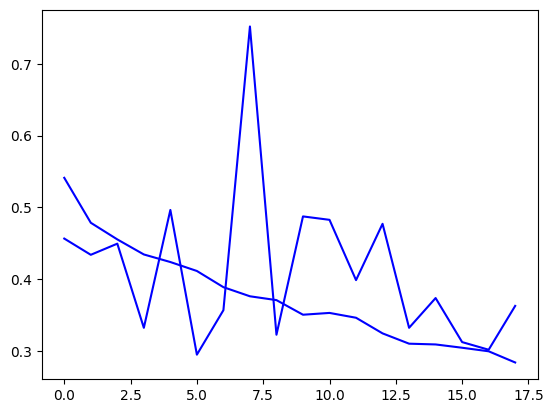

In [189]:
plt.plot(sample['train_losses'],'b')
plt.plot(sample['val_losses'],'b')

In [6]:


# Check validation set size and composition
with open(os.path.join(Config.dir_testTrainData, 'train_val_test_split.pkl'), 'rb') as f:
    split_info = pickle.load(f)

val_files = split_info['val_files']
test_files = split_info['test_files']

print(f"Val files: {len(val_files)}")
print(f"Test files: {len(test_files)}")

# Check wheeze distribution
val_wheezes = []
test_wheezes = []

for f in val_files:
    sample = data_Acq(os.path.join(Config.dir_preprocessed, f))
    val_wheezes.append(1 if sample['label'] in [2, 3] else 0)

for f in test_files:
    sample = data_Acq(os.path.join(Config.dir_preprocessed, f))
    test_wheezes.append(1 if sample['label'] in [2, 3] else 0)

print(f"\nVal wheeze rate: {100*np.mean(val_wheezes):.1f}%")
print(f"Test wheeze rate: {100*np.mean(test_wheezes):.1f}%")

Val files: 863
Test files: 760

Val wheeze rate: 14.1%
Test wheeze rate: 33.4%
